In [1]:
# Configure parameters and path names for segmentation

experiment = 'WTC11_CRE300_4_17_2024'
segname = 'dapi'
data_folder = r'Z:\Zane_20CRE\04_17_2024_300CREsScope2_WTC11D3_RNA_60X'
save_dir = f'/home/zgibbs/STARR-FISH/cellpose/{experiment}/{segname}'

from ioMicro import read_im
import numpy as np
import glob
import zarr
import os

In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

import torch
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'NVIDIA RTX A6000'

In [6]:
!nvidia-smi

Thu Aug  1 14:04:56 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 552.12                 Driver Version: 552.12         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:21:00.0  On |                  N/A |
|  0%   43C    P8             13W /  170W |    1309MiB /  12288MiB |     10%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# map all the hybes
hybes =  glob.glob(data_folder+os.sep+'H*')
# map all the fovs
fovs = [os.path.basename(fl) for fl in glob.glob(hybes[0]+os.sep+'*.zarr')]
def get_Hi(fld): 
    try: return int(os.path.basename(fld)[1:]) 
    except: return -1
    
hybes = np.array(hybes)[np.argsort([get_Hi(hybe) for hybe in hybes ])]
fovs.sort()

In [6]:
# Identify and count files (fovs) to segment 

zarr_files = r'Z:\Zane_20CRE\04_17_2024_300CREsScope2_WTC11D3_RNA_60X\H8\Conv_zscan__*.zarr'
files = list(sorted(list(glob.glob(zarr_files))))
print(f"Found {len(files)} files to segment")

Found 131 files to segment


In [9]:
# Read image data from each fov using read_im function from ioMicro

im_path = r'Z:\Zane_20CRE\04_17_2024_300CREsScope2_WTC11D3_RNA_60X\H8\*'
imgs = [read_im(im_path) for im_path in files]
# imgs_DAPI = [read_im(im_path) for im_path in files]

In [10]:
imgs[15][3,:,:,:].shape

(50, 3000, 3000)

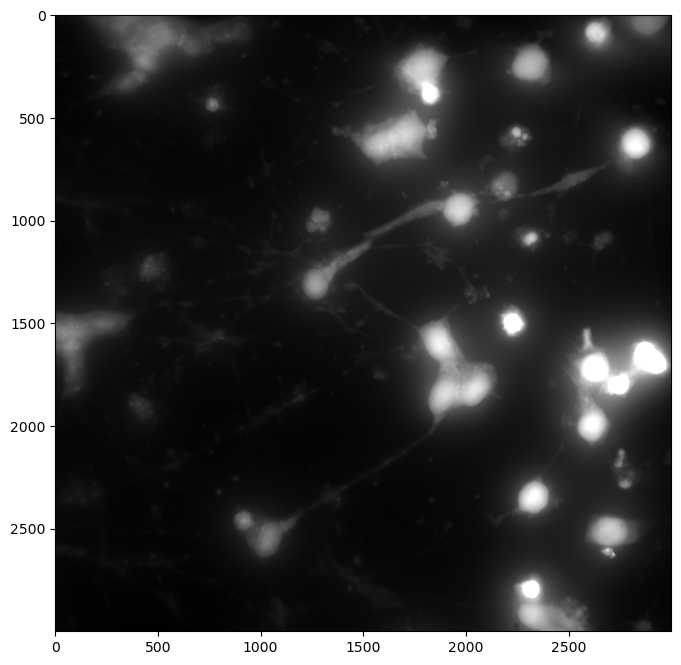

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(np.max(imgs[15][3,:,:], axis=0), cmap='gray', vmax=10000)

In [25]:
# RUN CELLPOSE FOR INDIVIDUAL FOVS TO TEST PARAMETERS
from cellpose import models, io
from tqdm import tqdm
import torch

# DEFINE CELLPOSE MODEL
# model_type='cyto2' or pretrained_model='<path_to_model>'
# pretrained_model=r'C:\Users\zgibbs\cellpose\HCT116_polyA_230320'

model = models.CellposeModel(gpu=True, model_type='nuclei',
                            device=torch.device(0))

masks, flows, styles = model.eval(imgs[60][3,20,:,:], channels=[0,0], diameter=20, do_3D=False,
                                 flow_threshold=0.75,cellprob_threshold=-5,stitch_threshold=0.5)

# Set the cell diameter manually (will determine automatically if 'None')
# Set the diameter to '0' if using a trained model
# HCT116 diameter = ~245

# masks, flows, styles = model.eval(imgs, channels=[0,0], diameter=0)

# masks, flows, styles = [], [], []

C:\Users\zgibbs\anaconda3\envs\cellpose2\lib\site-packages\cellpose\dynamics.py:378: RuntimeWarning: divide by zero encountered in scalar divide
  im[:,k,:,:] *= 2./shape[k]
C:\Users\zgibbs\anaconda3\envs\cellpose2\lib\site-packages\cellpose\dynamics.py:658: RuntimeWarning: invalid value encountered in cast
  pflows.append(p[i].flatten().astype('int32'))


IndexError: index -2147483628 is out of bounds for axis 1 with size 41

In [10]:
masks.ndim

2

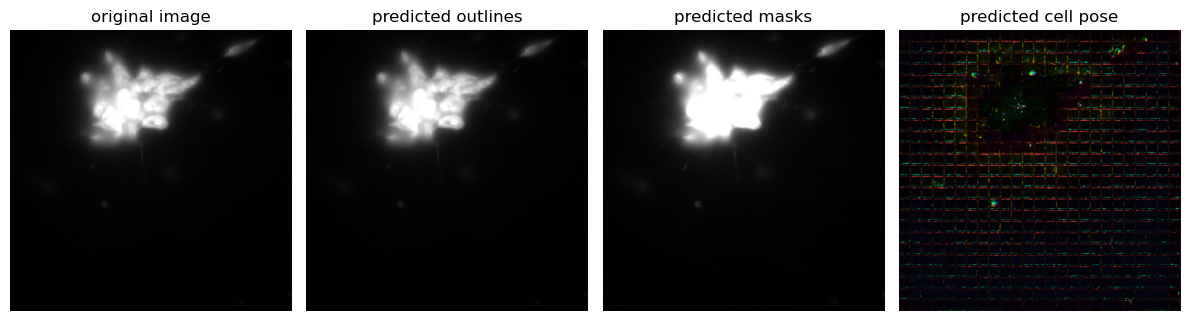

In [24]:
from cellpose import plot
import matplotlib.pyplot as plt

img1 = np.asarray(imgs[60][3,10,:,:], dtype=np.uint16) # convert image from dask array to numpy array

maski = masks
flowi = flows[0]

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img1, maski, flowi)
plt.tight_layout()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/ZaneTrit_3_3_2023/figures/cyto2_model_segmentation_plot.png', dpi=300)
plt.show()

In [7]:
torch.device(0)

device(type='cuda', index=0)

In [ ]:
torch.cuda.get_device_name(0)

In [ ]:
# Specify single polyA slice from each fov to use for segmentation 
# This is for polyA-based segmentation only

for i in range(100):
    imgs[i] = imgs[i][3,:,:,:]

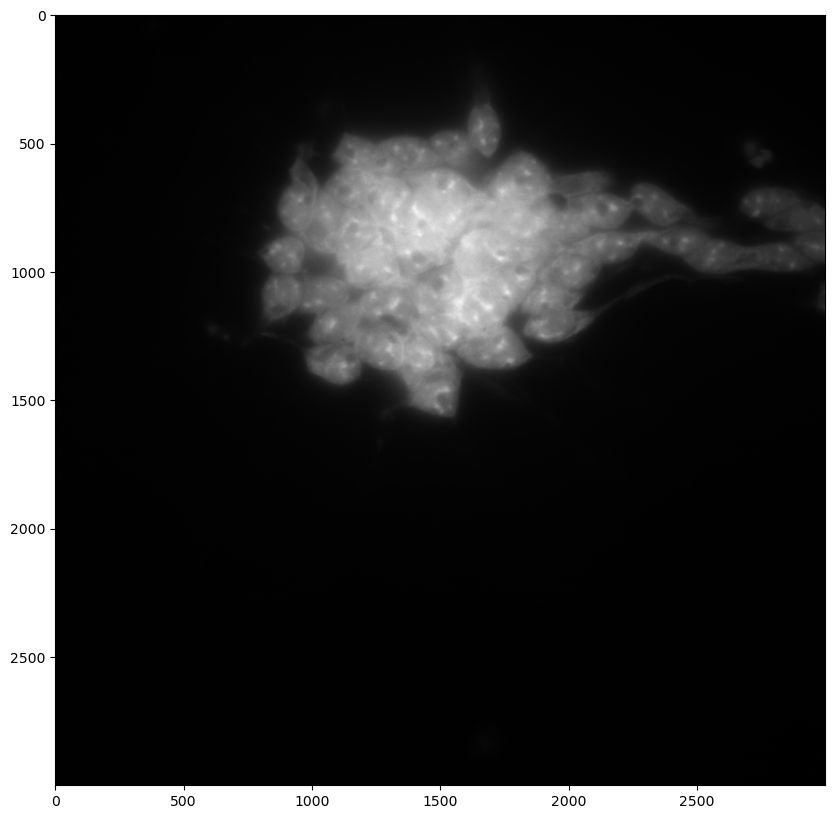

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,10))

ax.imshow(imgs[51][3,20,:,:], cmap='gray')

In [23]:
# Specify single polyA and DAPI slices from each fov to use for segmentation
# Combine polyA and DAPI into an 'rgb' type image for cellpose

# for i in range(134):
#     imgs_polyA[i] = imgs[i][2,20,:,:]
#     imgs_DAPI[i] = imgs[i][3,20,:,:]
    
# imgs = np.dstack((imgs_polyA, imgs_DAPI, imgs_DAPI))

IndexError: too many indices for array: array is 2-dimensional, but 4 were indexed

In [38]:
# Specify single polyA and DAPI slices from each fov to use for segmentation
# Combine polyA and DAPI into an 'rgb' type image for cellpose

for i in range(134):
    imgs[i] = np.dstack((np.zeros_like(imgs[i][2,20,:,:]),imgs[i][2,20,:,:], imgs[i][3,20,:,:]))
    
# imgs = np.dstack((imgs_polyA, imgs_DAPI, imgs_DAPI))

## Run cellpose

In [23]:
# RUN CELLPOSE FOR ALL FOVS
from cellpose import models, io
from tqdm import tqdm

# DEFINE CELLPOSE MODEL
# model_type='cyto2' or pretrained_model='<path_to_model>'

model = models.CellposeModel(gpu=False, pretrained_model='/tscc/projects/ps-renlab2/zgibbs/cellpose/models/HCT116_polyA_230320')

# Set the cell diameter manually (will determine automatically if 'None')
# Set the diameter to '0' if using a trained model
# HCT116 diameter = ~245

# masks, flows, styles = model.eval(imgs, channels=[0,0], diameter=0)

masks, flows, styles = [], [], []
for img in tqdm(imgs, desc='Segmented FOVs'):
    mask, flow, style = model.eval(img, channels=[0,0], diameter=0)
    masks.append(mask)
    flows.append(flow)
    styles.append(style)

Segmented FOVs: 100%|██████████| 308/308 [18:17:44<00:00, 213.85s/it]  


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import expand_labels

newmasks = []

for mask in masks:
    newmask = mask.copy()
    for cellid, size in zip(*np.unique(mask, return_counts=True)):
        if size < 2500:
            newmask[newmask==cellid] = 0
    newmask = expand_labels(newmask, 3)
    newmasks.append(newmask)

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(imgs[50], cmap='gray')
ax.contour(newmasks[50], [0.5+x for x in np.unique(newmasks[50])], colors='b')

KeyboardInterrupt: 

In [25]:
os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

io.masks_flows_to_seg(imgs, newmasks, flows, file_names=savefiles, diams=0) # use 'diams=0' here for pre-trained model
io.save_to_png(imgs, newmasks, flows, file_names=savefiles)

In [15]:
# RUN CELLPOSE FOR INDIVIDUAL FOVS TO TEST PARAMETERS
from cellpose import models, io
from tqdm import tqdm

# DEFINE CELLPOSE MODEL
# model_type='cyto2' or pretrained_model='<path_to_model>'

model = models.CellposeModel(gpu=False, pretrained_model='/projects/ps-renlab2/zgibbs/cellpose/models/HCT116_polyA_230320')

# Set the cell diameter manually (will determine automatically if 'None')
# Set the diameter to '0' if using a trained model
# HCT116 diameter = ~245

# masks, flows, styles = model.eval(imgs, channels=[0,0], diameter=0)

masks, flows, styles = [], [], []

mask, flow, style = model.eval(imgs[60], channels=[0,0], diameter=0)
masks.append(mask)
flows.append(flow)
styles.append(style)

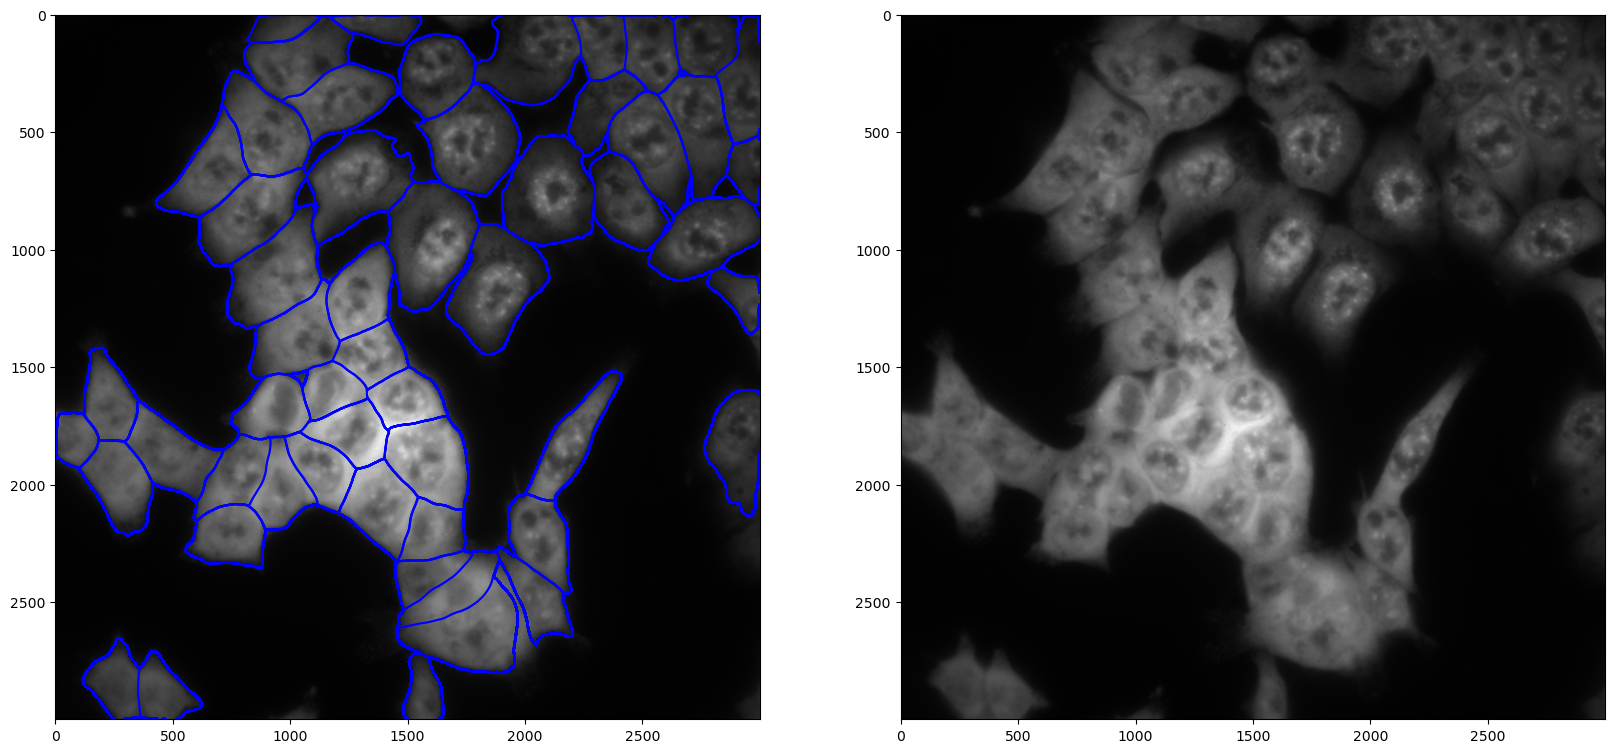

In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(20,10))

axs[0].imshow(imgs[14], cmap='gray')
axs[0].contour(newmasks[14], [0.5+x for x in np.unique(newmasks[14])], colors='b')

axs[1].imshow(imgs[14], cmap='gray')

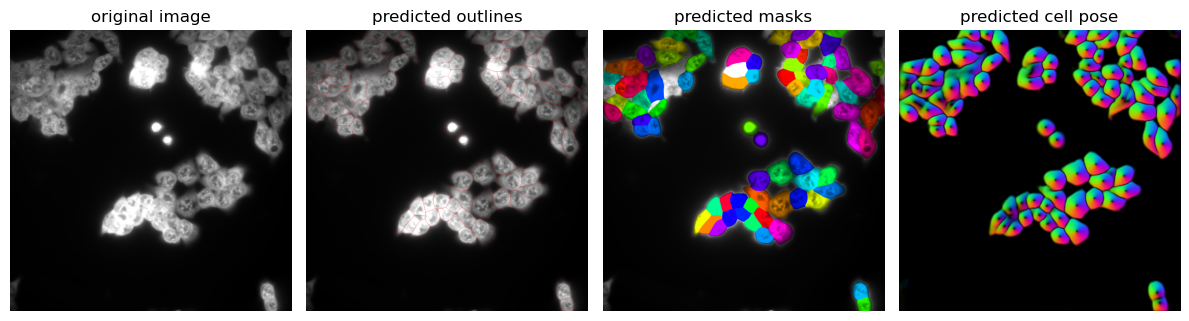

In [15]:
from cellpose import plot

img1 = np.asarray(imgs[60], dtype=np.uint16) # convert image from dask array to numpy array

maski = masks[0]
flowi = flows[0]

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img1, maski, flowi[0])
plt.tight_layout()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/ZaneTrit_3_3_2023/figures/cyto2_model_segmentation_plot.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import expand_labels

newmasks = []

for mask in masks:
    newmask = mask.copy()
    for cellid, size in zip(*np.unique(mask, return_counts=True)):
        if size < 2500:
            newmask[newmask==cellid] = 0
    newmask = expand_labels(newmask, 3)
    newmasks.append(newmask)

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(imgs[120], cmap='gray')
ax.contour(newmasks[120], [0.5+x for x in np.unique(newmasks[120])], colors='b')

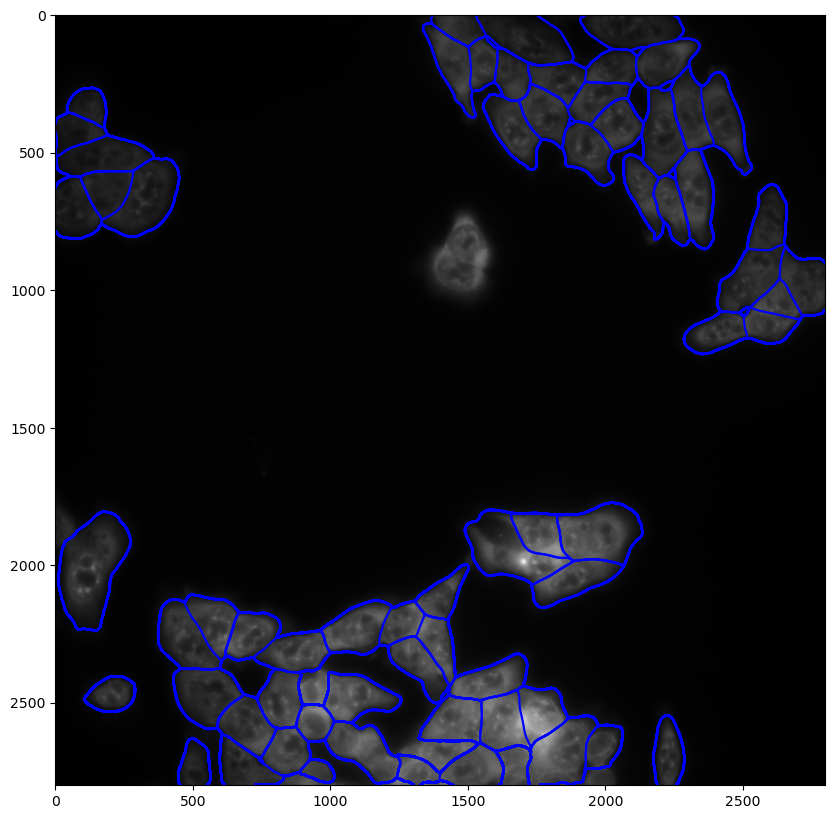

In [23]:
fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(imgs[43], cmap='gray')
ax.contour(newmasks[43], [0.5+x for x in np.unique(newmasks[43])], colors='b')

In [17]:
imgs[60]

dask.array<getitem, shape=(2800, 2800), dtype=uint16, chunksize=(2800, 2800), chunktype=numpy.ndarray>

### Save segmentation masks

In [24]:
# os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

In [25]:
savefiles

['/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__000.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__001.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__002.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__003.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__004.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__005.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__006.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__007.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__008.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Con

In [ ]:
os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

io.masks_flows_to_seg(imgs, newmasks, flows, file_names=savefiles, diams=0) # use 'diams=0' here for pre-trained model
io.save_to_png(imgs, newmasks, flows, file_names=savefiles)

### Plot cell centers and/or spots with the segmentation masks

In [1]:
import numpy as np
import pandas as pd

seg11_masks = np.load('/projects/ps-renlab2/zgibbs/cellpose/ZaneTrit_3_3_2023/polyA_slice30/Conv_zscan__11_seg.npy', allow_pickle=True)[()]
seg11_coords = pd.read_csv('/projects/ps-renlab2/zgibbs/cellpose/ZaneTrit_3_3_2023/polyA_slice30/Conv_zscan__11_cp_outlines.txt', names=list(range(0,3500)), header=None)

In [2]:
# calculate the mean x,y coordinates for each cell in the FOV
x_coord = seg11_coords.loc[:, ::2].mean(axis=1)
y_coord = seg11_coords.loc[:, 1::2].mean(axis=1)

# create new dataframe with x,y coords and cell number in the FOV
rows = x_coord.count()
cell_num = list(range(1,rows+1))
d = {'x': x_coord, 'y': y_coord, 'mask': cell_num}
df = pd.DataFrame(data=d)

In [9]:
YFP_A750 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/analysis/Conv_zscan__12--H_GFP_fits_icol0.npz', allow_pickle=True)
YFP_A750 = dict(YFP_A750)
YFP_A750['Xh']

brightness = YFP_A750['Xh'][:,7]
keep = brightness > 2500 # filter spots based on brightness (can filter based on other criteria too)
x = YFP_A750['Xh'][keep,1] # keep x coords that meet this threshold
y = YFP_A750['Xh'][keep,2] # keep y coords that meet this threshold

# Each column in decoded output array:
# 0) zc
# 1) xc
# 2) yc
# 3) bk (?)
# 4) a
# 5) habs
# 6) correlation with PSF
# 7) h (brightness)

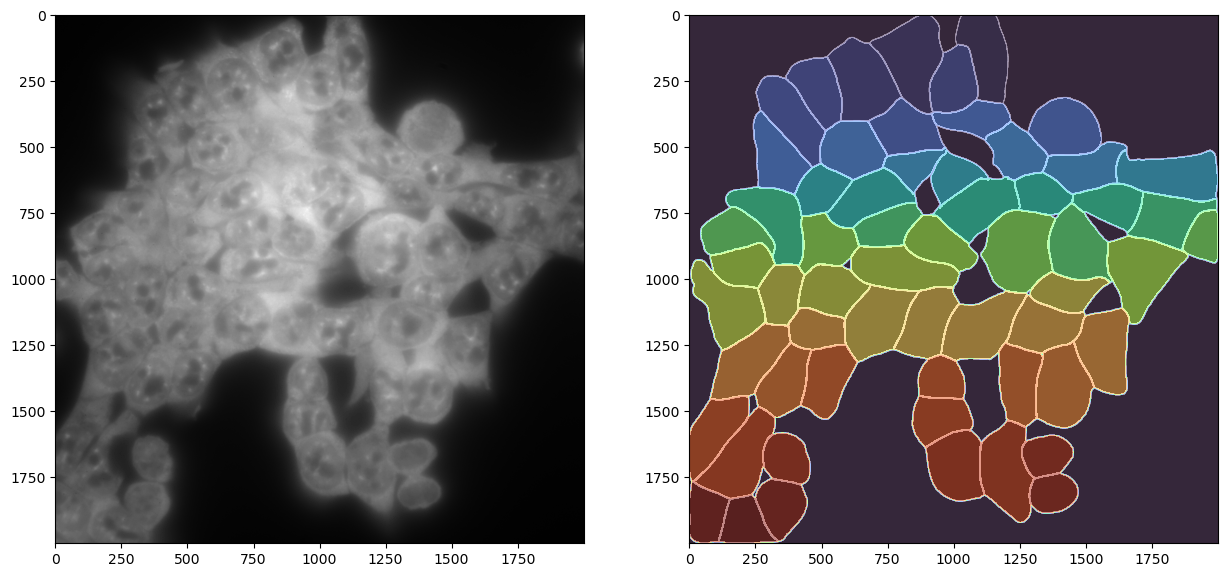

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(15,10))

axs[0].imshow(imgs[11], cmap='gray')
axs[1].imshow(seg11_masks['masks'], cmap = 'turbo', alpha=0.8)
axs[1].imshow(seg11_masks['outlines'], cmap = 'binary_r', alpha=0.4, vmax=0.1)
# plt.scatter(df['x'], df['y'], color='k', s=5) # cell centers
# plt.scatter(y, x, color='r', s=1, alpha=0.5) # YFP spots

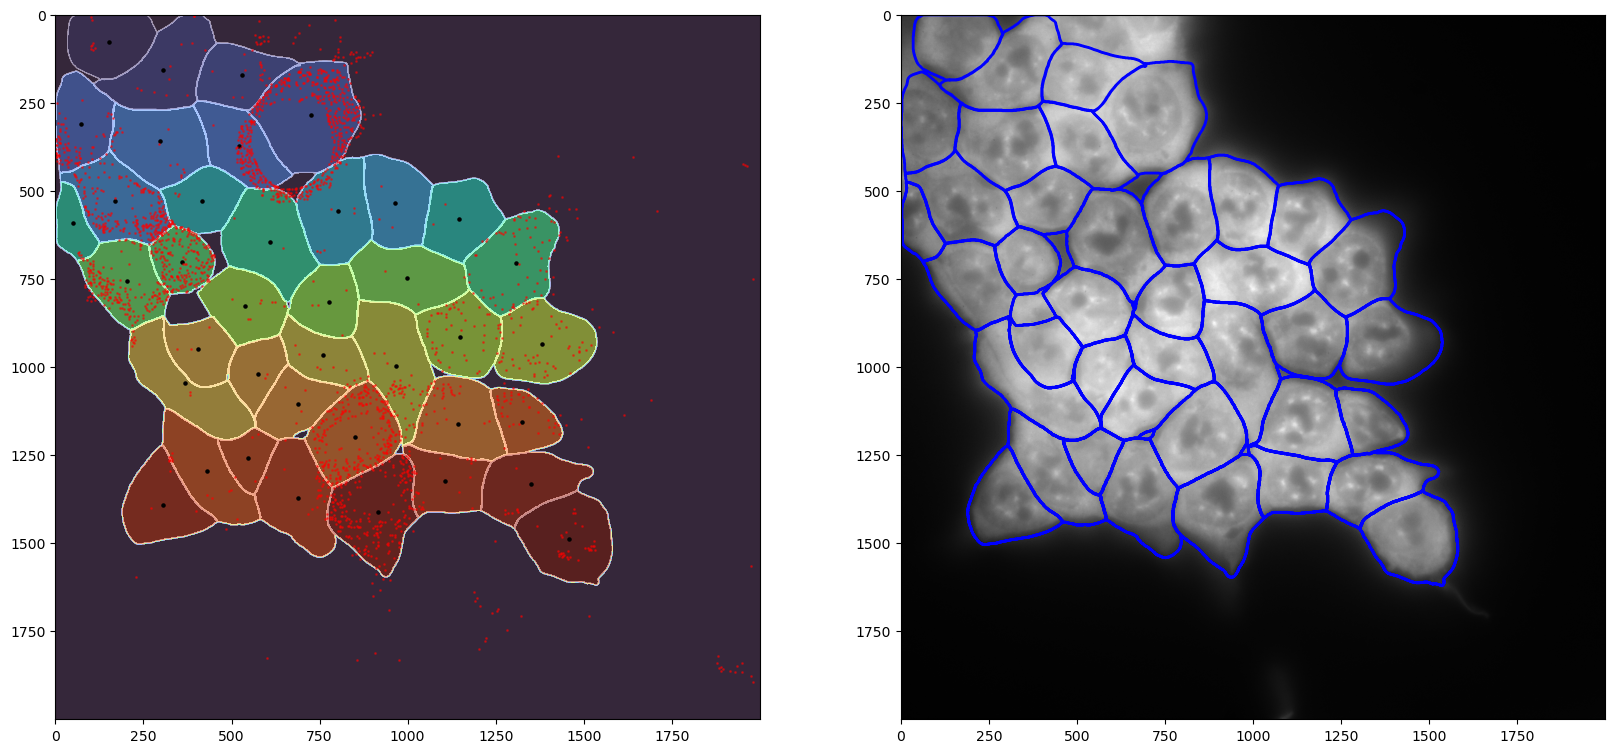

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(20,15))

axs[0].imshow(seg12_masks['masks'], cmap = 'turbo', alpha=0.8)
axs[0].imshow(seg12_masks['outlines'], cmap = 'binary_r', alpha=0.4, vmax=0.1)
axs[0].scatter(df['x'], df['y'], color='k', s=5) # cell centers
axs[0].scatter(y, x, color='r', s=1, alpha=0.5) # YFP spots

axs[1].imshow(imgs[12][2, 30, :, :], cmap='gray')
axs[1].contour(seg12_masks['outlines'], colors='blue')